# EndoScan — Structured Symptom Classifier
## CRISP-DM Data Science Lifecycle
---
**Project:** EndoScan ESI Score — Structured Questionnaire Path  
**Model:** LightGBM Binary Classifier → Probability → ESI Score (1–100) → Tier  
**Methodology:** CRISP-DM (6 phases)  
**Dataset:** `endo_data_csv.xls` — 480,000 patient records  

---
### Architecture Context
```
NLP Path (live)        → free-text symptoms     → ESI score + tier ─┐
Structured Path (this) → questionnaire answers  → ESI score + tier ─┴─► Fusion Layer → Unified ESI
```


---
## Phase 1 — Business Understanding
Define the objective, success criteria, and feature contract before touching data.


In [5]:
# Phase 1 — Business Understanding
# No computation here — documented as the project contract

BUSINESS_OBJECTIVE = """
EndoScan is a clinical decision-support tool for endometriosis triage.
The structured classifier ingests questionnaire answers and outputs:
  - ESI Score  : integer 1–100
  - ESI Tier   : Low / Moderate / High / Critical
  - Description: Clinical action recommendation

Both the NLP path and this structured path produce the same output
format so the fusion layer can combine them into one unified result.
"""

ESI_TIERS = {
    'Low':      (1,  25,  'Minimal indicators — routine monitoring'),
    'Moderate': (26, 50,  'Moderate indicators — follow up 4–6 weeks'),
    'High':     (51, 75,  'Strong indicators — specialist referral within 2 weeks'),
    'Critical': (76, 100, 'Severe presentation — urgent specialist referral'),
}

SUCCESS_CRITERIA = {
    'AUC':      0.92,   # minimum acceptable
    'F1':       0.88,   # minimum acceptable
}

FEATURE_CONTRACT = {
    # Continuous / demographic
    'Age':                  'Patient age (years)',
    'BMI':                  'Body mass index',
    'Cycle_Length':         'Menstrual cycle length (days)',
    'Age_of_Menarche':      'Age at first period',
    # Symptom severity scores 0–10
    'Dysmenorrhea_Score':   'Painful periods severity (0–10)',
    'Pelvic_Pain_Score':    'Pelvic pain severity (0–10)',
    'Dyspareunia_Score':    'Pain during intercourse (0–10)',
    'Dyschezia_Score':      'Painful bowel movements (0–10)',
    'Urinary_Symptoms_Score':'Urinary symptoms severity (0–10)',
    'Mental_Health_Score':  'Mental health impact (0–10)',
    # History flags
    'Family_History':       'Family history of endometriosis (0/1)',
    'Infertility_Status':   'Infertility flag (0/1)',
}

EXCLUDED_FEATURES = {
    'CA_125_Level': 'Lab result — missing in 83% of rows, not a questionnaire input',
    'CRP_Level':    'Lab result — same reason',
}

print("Phase 1 — Business Understanding")
print("=" * 50)
print(f"Features in scope : {len(FEATURE_CONTRACT)}")
print(f"Features excluded : {len(EXCLUDED_FEATURES)}")
print(f"\nESI Tier Boundaries:")
for tier, (lo, hi, action) in ESI_TIERS.items():
    print(f"  {tier:<10} {lo:>3}–{hi:<3}  {action}")
print(f"\nSuccess criteria  : AUC ≥ {SUCCESS_CRITERIA['AUC']}  |  F1 ≥ {SUCCESS_CRITERIA['F1']}")


Phase 1 — Business Understanding
Features in scope : 12
Features excluded : 2

ESI Tier Boundaries:
  Low          1–25   Minimal indicators — routine monitoring
  Moderate    26–50   Moderate indicators — follow up 4–6 weeks
  High        51–75   Strong indicators — specialist referral within 2 weeks
  Critical    76–100  Severe presentation — urgent specialist referral

Success criteria  : AUC ≥ 0.92  |  F1 ≥ 0.88


---
## Phase 2 — Data Understanding
Structural audit, quality issues, and exploratory data analysis (EDA).


In [6]:
# Imports & global config
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ─────────────────────────────────────────────────────
PALETTE   = {'Low': '#4CAF50', 'Moderate': '#FF9800', 'High': '#F44336', 'Critical': '#9C27B0'}
ESI_ORDER = ['Low', 'Moderate', 'High', 'Critical']
ACCENT    = '#7C83FD'

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d', 'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#b0b0b0', 'ytick.color':      '#b0b0b0',
    'text.color':       '#e0e0e0', 'grid.color':       '#2a2d3d',
    'grid.linestyle':   '--',      'grid.alpha':        0.5,
    'font.family':      'DejaVu Sans',
})

FEATURES = [
    'Age', 'BMI', 'Cycle_Length', 'Age_of_Menarche',
    'Dysmenorrhea_Score', 'Pelvic_Pain_Score', 'Dyspareunia_Score',
    'Dyschezia_Score', 'Urinary_Symptoms_Score', 'Mental_Health_Score',
    'Family_History', 'Infertility_Status'
]
SCORE_COLS = [
    'Dysmenorrhea_Score', 'Pelvic_Pain_Score', 'Dyspareunia_Score',
    'Dyschezia_Score', 'Urinary_Symptoms_Score', 'Mental_Health_Score'
]
CONTINUOUS = ['Age', 'BMI', 'Cycle_Length', 'Age_of_Menarche']

print("Imports OK ✓")


Imports OK ✓


In [7]:
# ── 2.1  Load raw data ────────────────────────────────────────────
#DATA_PATH = '/mnt/user-data/uploads/endo_data_csv.xls'   # adjust if running locally
df_raw = pd.read_csv("endo_data.csv.xls", dtype=str)

print(f"Raw shape  : {df_raw.shape}")
print(f"Columns    : {df_raw.columns.tolist()}")
df_raw.head(5)


Raw shape  : (480080, 15)
Columns    : ['Age', 'BMI', 'Cycle_Length', 'Age_of_Menarche', 'Dysmenorrhea_Score', 'Pelvic_Pain_Score', 'Dyspareunia_Score', 'Dyschezia_Score', 'Urinary_Symptoms_Score', 'Family_History', 'Infertility_Status', 'CA_125_Level', 'CRP_Level', 'Mental_Health_Score', 'Endometriosis_Stage']


,Age,BMI,Cycle_Length,Age_of_Menarche,Dysmenorrhea_Score,Pelvic_Pain_Score,Dyspareunia_Score,Dyschezia_Score,Urinary_Symptoms_Score,Family_History,Infertility_Status,CA_125_Level,CRP_Level,Mental_Health_Score,Endometriosis_Stage
0,43,33.79,38,17,10,0,4,10,0,false,false,1052.771,185.966,0,false
1,36,10.61,45,9,5,10,7,2,7,true,false,124.108,82.589,3,true
2,36,24.58,34,9,4,5,2,10,7,false,true,236.559,0.547,3,false
3,14,12.8,52,9,4,6,5,2,8,false,true,697.311,49.582,2,false
4,53,16.55,32,14,1,7,2,6,4,true,false,150.675,285.178,8,false


In [8]:
# ── 2.2  Structural quality checks ───────────────────────────────
print("Target unique values :", df_raw['Endometriosis_Stage'].unique().tolist())
print()

# Embedded header rows (column names repeated mid-file)
header_rows = df_raw[df_raw['Endometriosis_Stage'] == 'Endometriosis_Stage']
print(f"Embedded header rows : {len(header_rows)}")
print(f"At row indices       : {header_rows.index[:5].tolist()} ...")

# Sub-dataset segments
mask_int  = df_raw['Endometriosis_Stage'].isin(['0','1'])
mask_bool = df_raw['Endometriosis_Stage'].isin(['true','false'])
print(f"\nSegment A — int  0/1 (no labs) : {mask_int.sum():>7,} rows")
print(f"Segment B — bool target (labs) : {mask_bool.sum():>7,} rows")
print(f"Segment C — header/null rows   : {(~mask_int & ~mask_bool).sum():>7,} rows")

# Boolean encoding variants
for col in ['Family_History', 'Infertility_Status']:
    print(f"\n{col} unique : {df_raw[col].unique().tolist()}")


Target unique values : ['false', 'true', '0', '1', 'Endometriosis_Stage', nan]

Embedded header rows : 79
At row indices       : [6000, 12001, 18002, 24003, 30004] ...

Segment A — int  0/1 (no labs) : 400,000 rows
Segment B — bool target (labs) :  80,000 rows
Segment C — header/null rows   :      80 rows

Family_History unique : ['false', 'true', '1', '0', 'Family_History', nan]

Infertility_Status unique : ['false', 'true', '0', '1', 'Infertility_Status', nan]


In [9]:
# ── 2.3  Clean & standardise ─────────────────────────────────────
df = df_raw.copy()

# Drop embedded header rows + null targets
df = df[~df['Endometriosis_Stage'].isin(['Endometriosis_Stage'])]
df = df.dropna(subset=['Endometriosis_Stage'])

# Unified binary target
df['target'] = df['Endometriosis_Stage'].map(
    {'0': 0, '1': 1, 'false': 0, 'true': 1}
).astype(float)
df = df.dropna(subset=['target'])
df['target'] = df['target'].astype(int)

# Normalise boolean columns
bool_map = {'0': 0, '1': 1, 'true': 1, 'false': 0, True: 1, False: 0}
for col in ['Family_History', 'Infertility_Status']:
    df[col] = df[col].map(bool_map)

# Numeric coercion for all feature columns
all_num = FEATURES + ['CA_125_Level', 'CRP_Level']
for col in all_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Rows after cleaning  : {len(df):,}")
print(f"\nTarget distribution:")
print(df['target'].value_counts().rename({0:'Negative (0)', 1:'Positive (1)'}))
print(f"\nClass balance: {df['target'].mean():.1%} positive")


Rows after cleaning  : 480,000

Target distribution:
target
Negative (0)    260054
Positive (1)    219946
Name: count, dtype: int64

Class balance: 45.8% positive


In [10]:
# ── 2.4  Missing value analysis ──────────────────────────────────
missing = df[FEATURES + ['target']].isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
mv_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
mv_df = mv_df[mv_df['Missing Count'] > 0]

if len(mv_df) == 0:
    print("✓ No missing values in working features after cleaning")
else:
    print(mv_df)


✓ No missing values in working features after cleaning


In [11]:
# ── 2.5  Outlier detection (IQR method) ──────────────────────────
print(f"{'Feature':<26} {'Range':>16}  {'IQR Outliers':>14}  {'Outlier %':>10}")
print("-" * 72)
for col in CONTINUOUS:
    vals = df[col].dropna()
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((vals < lo) | (vals > hi)).sum()
    print(f"{col:<26} [{vals.min():>5.1f}, {vals.max():>5.1f}]  "
          f"{n_out:>12,}  {n_out/len(vals)*100:>9.2f}%")

print()
print("Score columns (valid range 0–10):")
for col in SCORE_COLS:
    oor = ((df[col] < 0) | (df[col] > 10)).sum()
    print(f"  {col:<28} out-of-range: {oor}")

print("\nNote: IQR outliers in continuous features are clinically valid")
print("(e.g. age 12 or BMI 10 are real edge cases). No removal needed.")


Feature                               Range    IQR Outliers   Outlier %
------------------------------------------------------------------------
Age                        [ 12.0,  60.0]             0       0.00%
BMI                        [ 10.0,  60.0]        22,527       4.69%
Cycle_Length               [ 15.0,  60.0]        27,843       5.80%
Age_of_Menarche            [  8.0,  20.0]        12,302       2.56%

Score columns (valid range 0–10):
  Dysmenorrhea_Score           out-of-range: 0
  Pelvic_Pain_Score            out-of-range: 0
  Dyspareunia_Score            out-of-range: 0
  Dyschezia_Score              out-of-range: 0
  Urinary_Symptoms_Score       out-of-range: 0
  Mental_Health_Score          out-of-range: 0

Note: IQR outliers in continuous features are clinically valid
(e.g. age 12 or BMI 10 are real edge cases). No removal needed.


In [12]:
# ── 2.6  Descriptive statistics ──────────────────────────────────
desc = df[FEATURES].describe().round(3)
display(desc)


,Age,BMI,Cycle_Length,Age_of_Menarche,Dysmenorrhea_Score,Pelvic_Pain_Score,Dyspareunia_Score,Dyschezia_Score,Urinary_Symptoms_Score,Mental_Health_Score,Family_History,Infertility_Status
count,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000
mean,31.836,27.914,29.216,12.737,4.965,4.988,5.058,5.048,5.071,5.033,0.326,0.297
std,9.383,8.041,7.504,2.254,3.159,3.138,3.146,3.144,3.148,3.158,0.469,0.457
min,12.000,10.000,15.000,8.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,24.000,22.337,24.000,11.000,2.000,2.000,2.000,2.000,2.000,2.000,0.000,0.000
50%,32.000,27.037,28.000,13.000,5.000,5.000,5.000,5.000,5.000,5.000,0.000,0.000
75%,39.000,31.774,32.000,14.000,8.000,8.000,8.000,8.000,8.000,8.000,1.000,1.000
max,60.000,60.000,60.000,20.000,10.000,10.000,10.000,10.000,10.000,10.000,1.000,1.000


In [13]:
# ── 2.7  Skewness & Kurtosis ─────────────────────────────────────
print(f"{'Feature':<28}  {'Skew':>8}  {'Kurtosis':>10}  {'Flag'}")
print("-" * 60)
for col in FEATURES:
    sk = df[col].skew()
    kt = df[col].kurtosis()
    flag = "⚠ HIGH SKEW" if abs(sk) > 1 else ""
    print(f"{col:<28}  {sk:>8.3f}  {kt:>10.3f}  {flag}")

print("\nNote: High skew in BMI & Cycle_Length is expected (right-tailed)")
print("Tree-based models (LightGBM) are invariant to monotonic transforms,")
print("so no log-transform is needed.")


Feature                           Skew    Kurtosis  Flag
------------------------------------------------------------
Age                              0.351      -0.261  
BMI                              1.360       2.972  ⚠ HIGH SKEW
Cycle_Length                     1.782       4.175  ⚠ HIGH SKEW
Age_of_Menarche                  0.642       0.637  
Dysmenorrhea_Score               0.002      -1.224  
Pelvic_Pain_Score                0.020      -1.195  
Dyspareunia_Score               -0.022      -1.213  
Dyschezia_Score                 -0.008      -1.204  
Urinary_Symptoms_Score          -0.034      -1.197  
Mental_Health_Score             -0.020      -1.219  
Family_History                   0.741      -1.450  
Infertility_Status               0.889      -1.209  

Note: High skew in BMI & Cycle_Length is expected (right-tailed)
Tree-based models (LightGBM) are invariant to monotonic transforms,
so no log-transform is needed.


In [14]:
# ── 2.8  Feature–target correlations (point-biserial) ────────────
print(f"{'Feature':<28}  {'r':>8}  {'p-value':>12}  {'Sig'}")
print("-" * 58)
for col in FEATURES:
    corr, pval = stats.pointbiserialr(df[col].fillna(df[col].median()), df['target'])
    sig = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
    print(f"{col:<28}  {corr:>8.4f}  {pval:>12.2e}  {sig}")


Feature                              r       p-value  Sig
----------------------------------------------------------
Age                             0.0102      1.49e-12  ***
BMI                             0.0218      1.76e-51  ***
Cycle_Length                    0.0202      1.66e-44  ***
Age_of_Menarche                 0.0043      2.89e-03  **
Dysmenorrhea_Score              0.0864      0.00e+00  ***
Pelvic_Pain_Score               0.0930      0.00e+00  ***
Dyspareunia_Score               0.0915      0.00e+00  ***
Dyschezia_Score                 0.1017      0.00e+00  ***
Urinary_Symptoms_Score          0.0529     1.10e-294  ***
Mental_Health_Score             0.0157      1.31e-27  ***
Family_History                  0.2111      0.00e+00  ***
Infertility_Status              0.1688      0.00e+00  ***


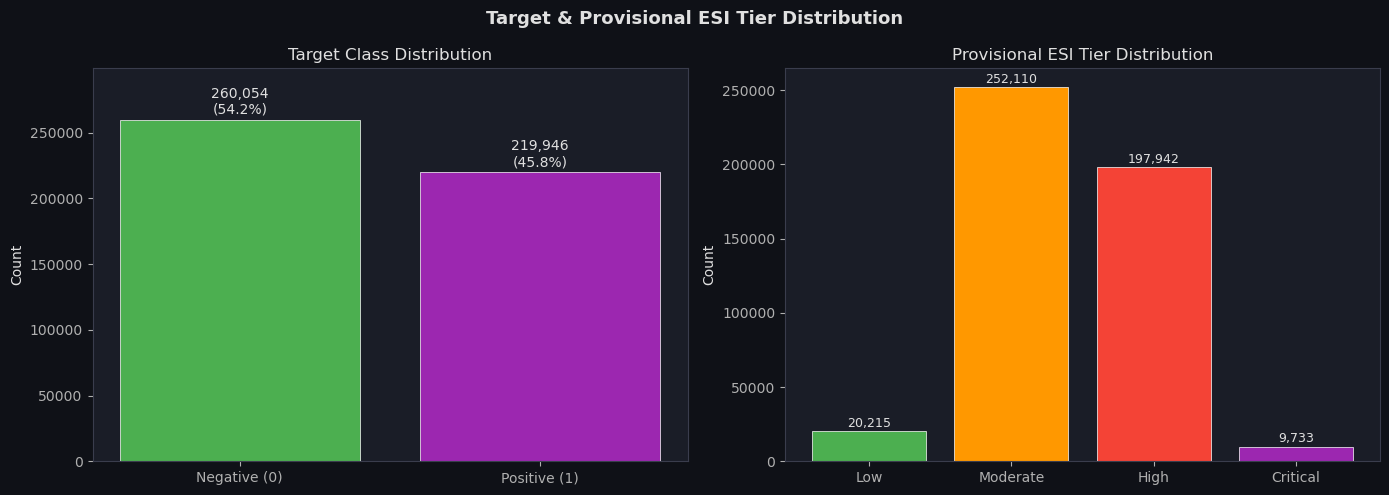

In [15]:
# ── 2.9 EDA Plot A: Target & Provisional ESI Tier Distribution ───
score_sum  = df[SCORE_COLS].sum(axis=1)
score_norm = (score_sum - score_sum.min()) / (score_sum.max() - score_sum.min())
df['esi_score_prov'] = (score_norm * 99 + 1).round().astype(int)

def score_to_tier(s):
    if   s <= 25: return 'Low'
    elif s <= 50: return 'Moderate'
    elif s <= 75: return 'High'
    else:         return 'Critical'

df['esi_tier_prov'] = df['esi_score_prov'].apply(score_to_tier)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target & Provisional ESI Tier Distribution', fontsize=13, fontweight='bold')

counts = df['target'].value_counts().sort_index()
bars = axes[0].bar(['Negative (0)', 'Positive (1)'], counts.values,
                    color=[PALETTE['Low'], PALETTE['Critical']],
                    edgecolor='white', linewidth=0.5)
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{count:,}\n({count/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, max(counts.values) * 1.15)

tier_counts = df['esi_tier_prov'].value_counts()[ESI_ORDER]
bars2 = axes[1].bar(ESI_ORDER, tier_counts.values,
                     color=[PALETTE[t] for t in ESI_ORDER],
                     edgecolor='white', linewidth=0.5)
axes[1].set_title('Provisional ESI Tier Distribution')
axes[1].set_ylabel('Count')
for bar, count in zip(bars2, tier_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


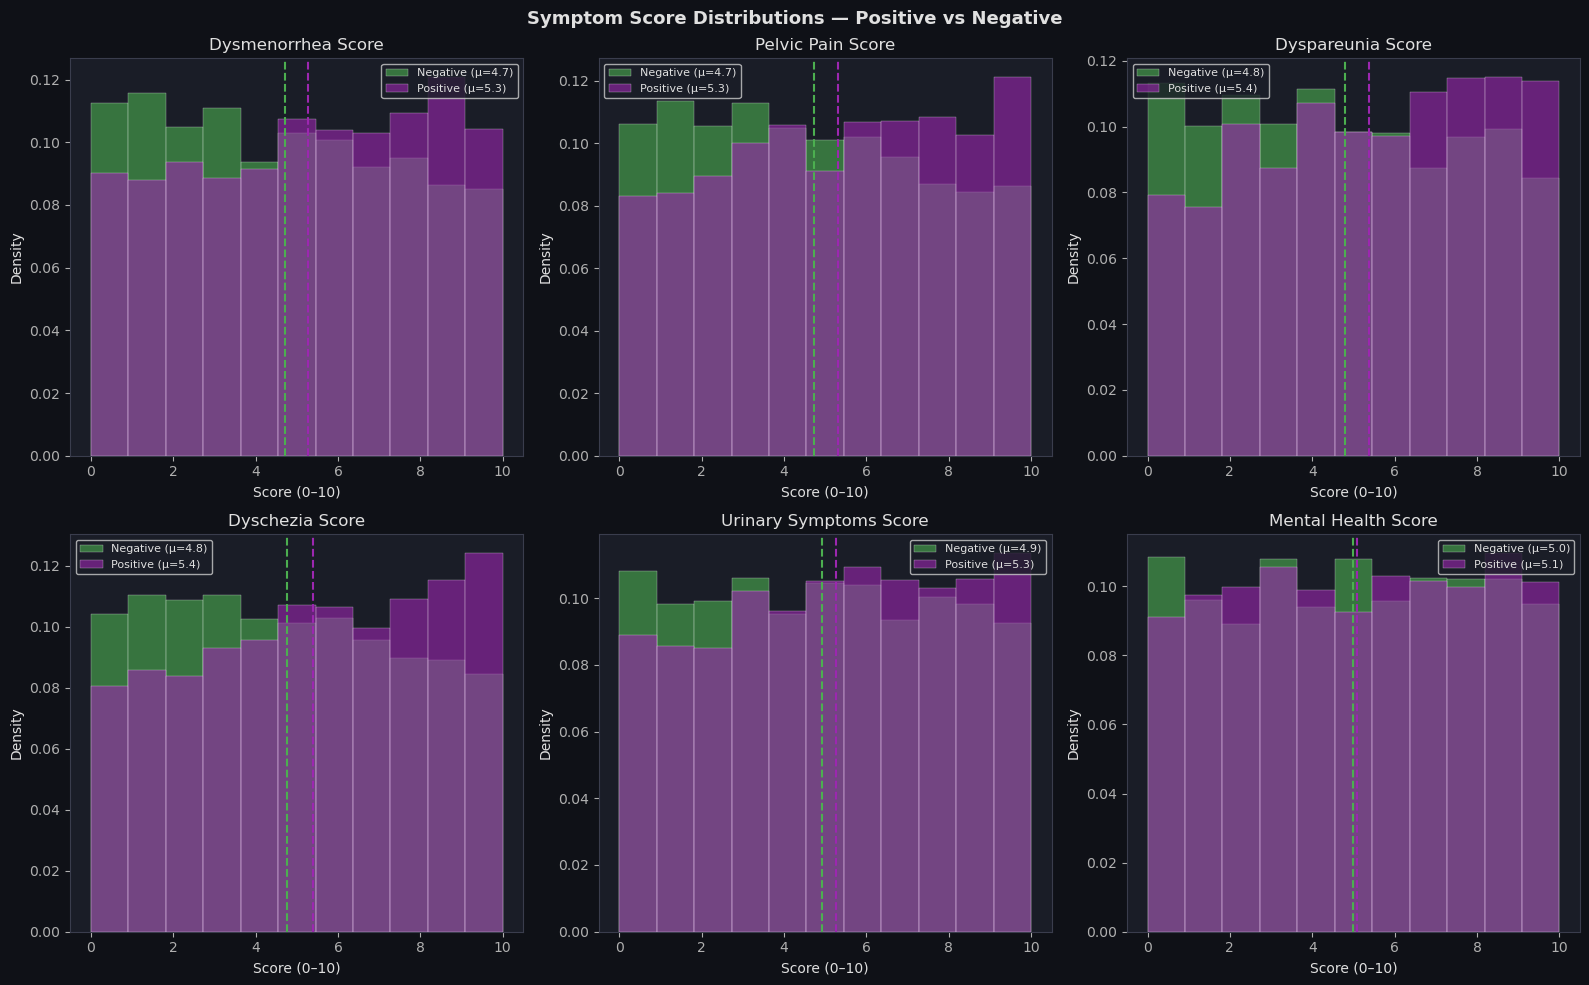

In [16]:
# ── 2.10 EDA Plot B: Symptom Score Distributions ────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Symptom Score Distributions — Positive vs Negative', fontsize=13, fontweight='bold')
axes = axes.flatten()
pos, neg = df[df['target']==1], df[df['target']==0]

for i, col in enumerate(SCORE_COLS):
    ax = axes[i]
    ax.hist(neg[col].dropna(),  bins=11, alpha=0.6, color=PALETTE['Low'],
            label=f'Negative (μ={neg[col].mean():.1f})', density=True, edgecolor='white', lw=0.3)
    ax.hist(pos[col].dropna(),  bins=11, alpha=0.6, color=PALETTE['Critical'],
            label=f'Positive (μ={pos[col].mean():.1f})', density=True, edgecolor='white', lw=0.3)
    ax.axvline(neg[col].mean(), color=PALETTE['Low'],      linestyle='--', lw=1.5)
    ax.axvline(pos[col].mean(), color=PALETTE['Critical'], linestyle='--', lw=1.5)
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('Score (0–10)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


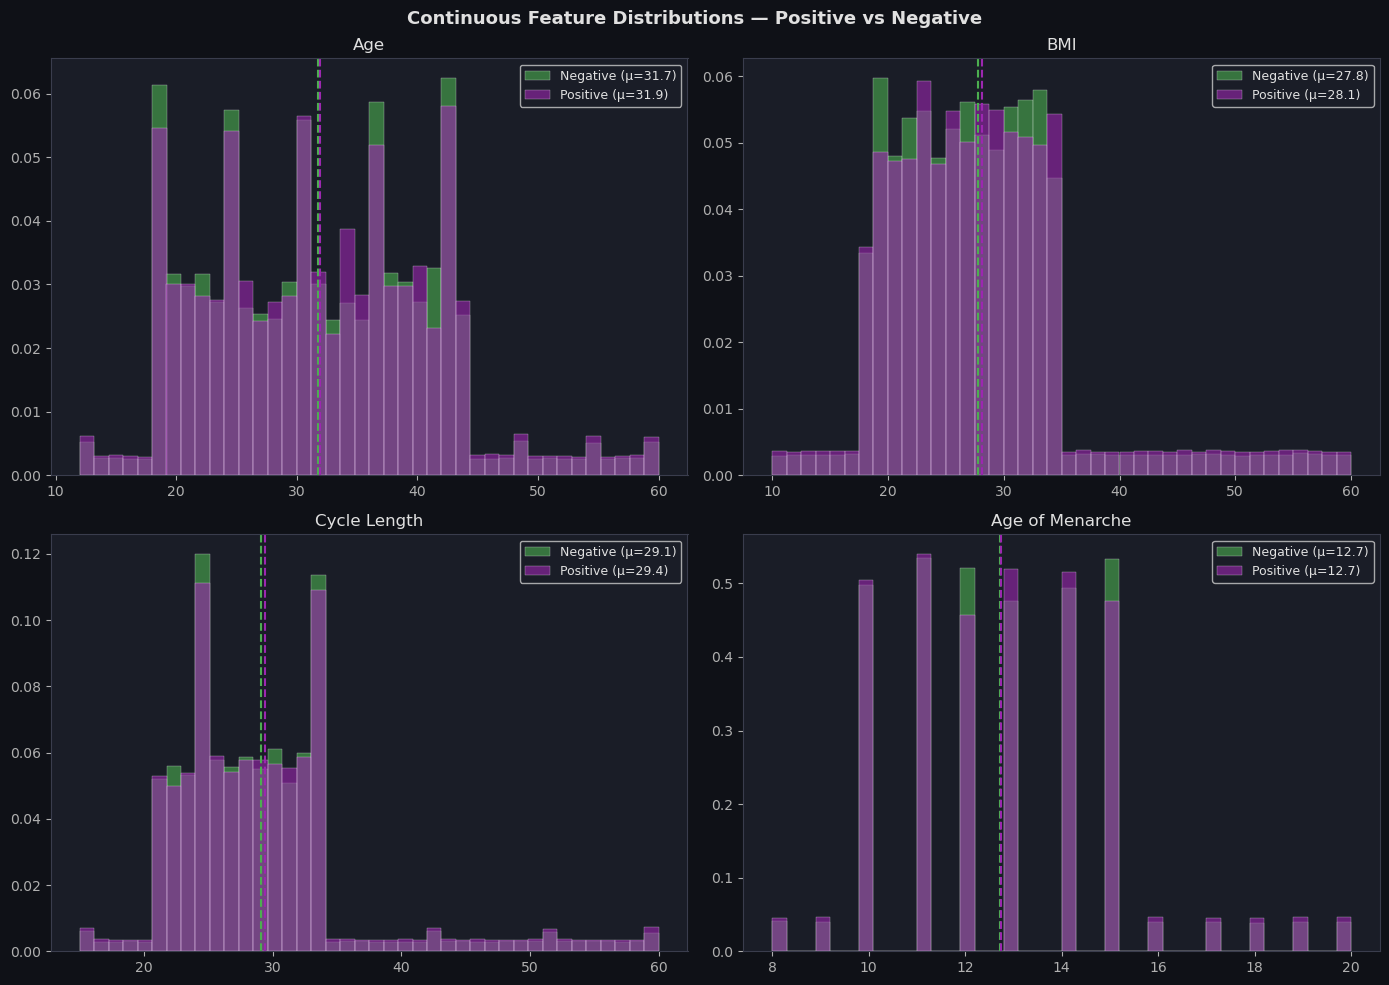

In [17]:
# ── 2.11 EDA Plot C: Continuous Features ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Continuous Feature Distributions — Positive vs Negative', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS):
    ax = axes[i]
    ax.hist(neg[col].dropna(), bins=40, alpha=0.6, color=PALETTE['Low'],
            label=f'Negative (μ={neg[col].mean():.1f})', density=True, edgecolor='white', lw=0.3)
    ax.hist(pos[col].dropna(), bins=40, alpha=0.6, color=PALETTE['Critical'],
            label=f'Positive (μ={pos[col].mean():.1f})', density=True, edgecolor='white', lw=0.3)
    ax.axvline(neg[col].mean(), color=PALETTE['Low'],      linestyle='--', lw=1.5)
    ax.axvline(pos[col].mean(), color=PALETTE['Critical'], linestyle='--', lw=1.5)
    ax.set_title(col.replace('_', ' '))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


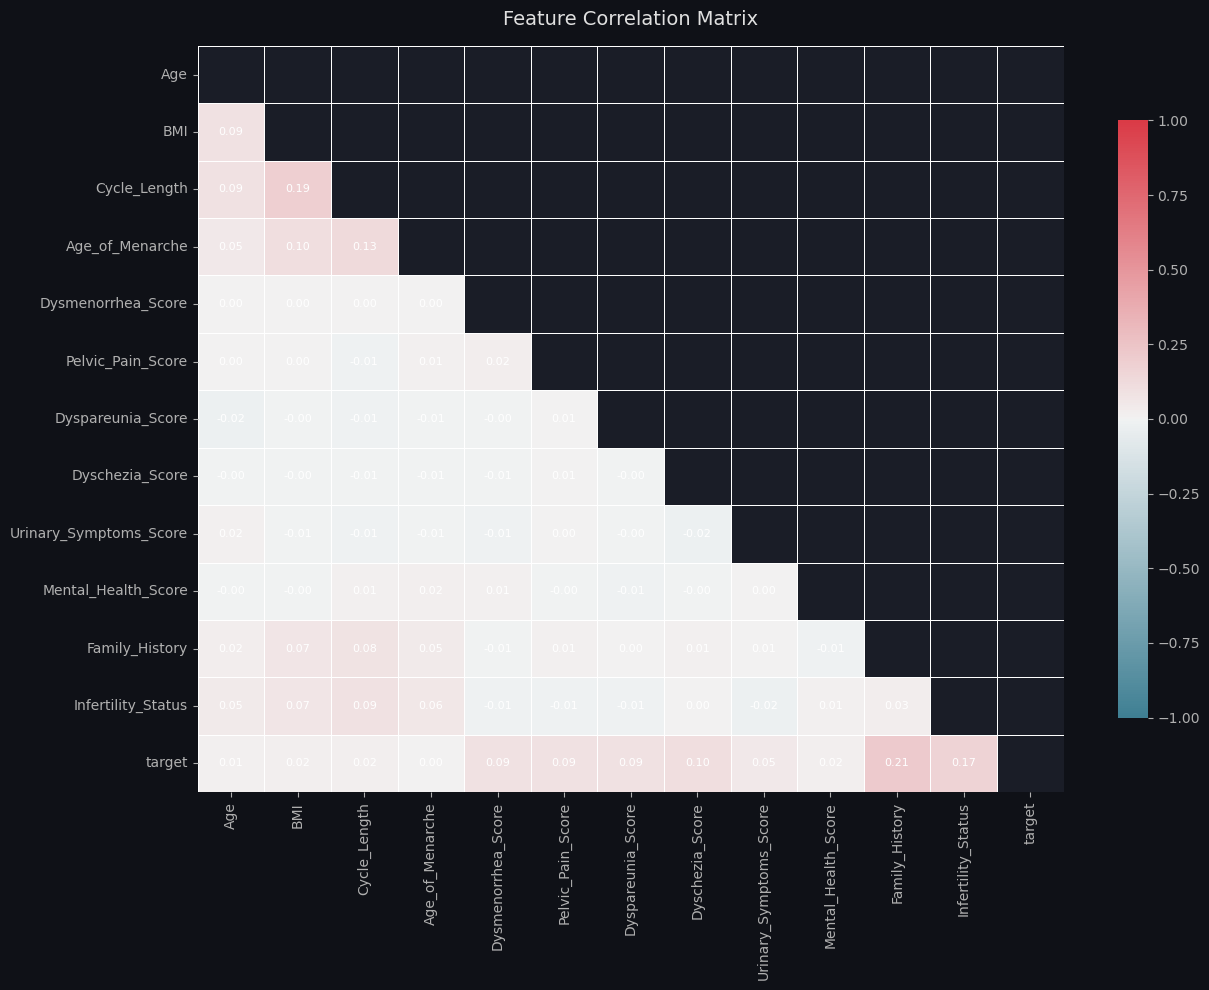


Key finding: moderate inter-symptom correlations (0.3–0.5).
No multicollinearity concern for tree-based models.


In [18]:
# ── 2.12 EDA Plot D: Correlation Heatmap ────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
corr_df = df[FEATURES + ['target']].corr()
mask    = np.triu(np.ones_like(corr_df, dtype=bool))
cmap    = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_df, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5,
            annot_kws={'size': 8, 'color': 'white'}, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("\nKey finding: moderate inter-symptom correlations (0.3–0.5).")
print("No multicollinearity concern for tree-based models.")


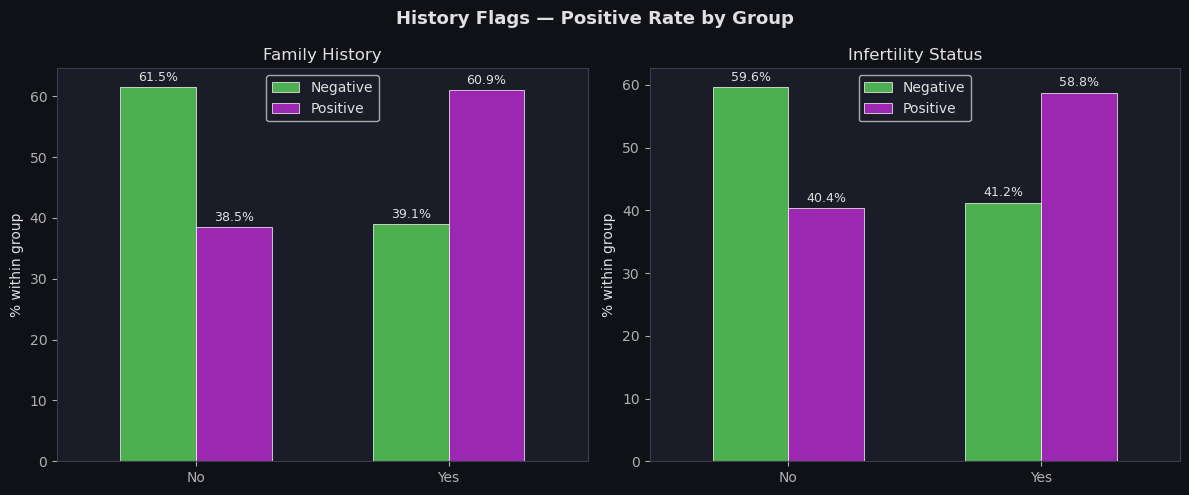

In [19]:
# ── 2.13 EDA Plot E: Binary History Flags ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('History Flags — Positive Rate by Group', fontsize=13, fontweight='bold')

for i, col in enumerate(['Family_History', 'Infertility_Status']):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.index = ['No', 'Yes']
    ct.columns = ['Negative', 'Positive']
    ct.plot(kind='bar', ax=axes[i],
            color=[PALETTE['Low'], PALETTE['Critical']],
            edgecolor='white', linewidth=0.5, width=0.6)
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_ylabel('% within group')
    axes[i].set_xticklabels(['No', 'Yes'], rotation=0)
    axes[i].legend()
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%',
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


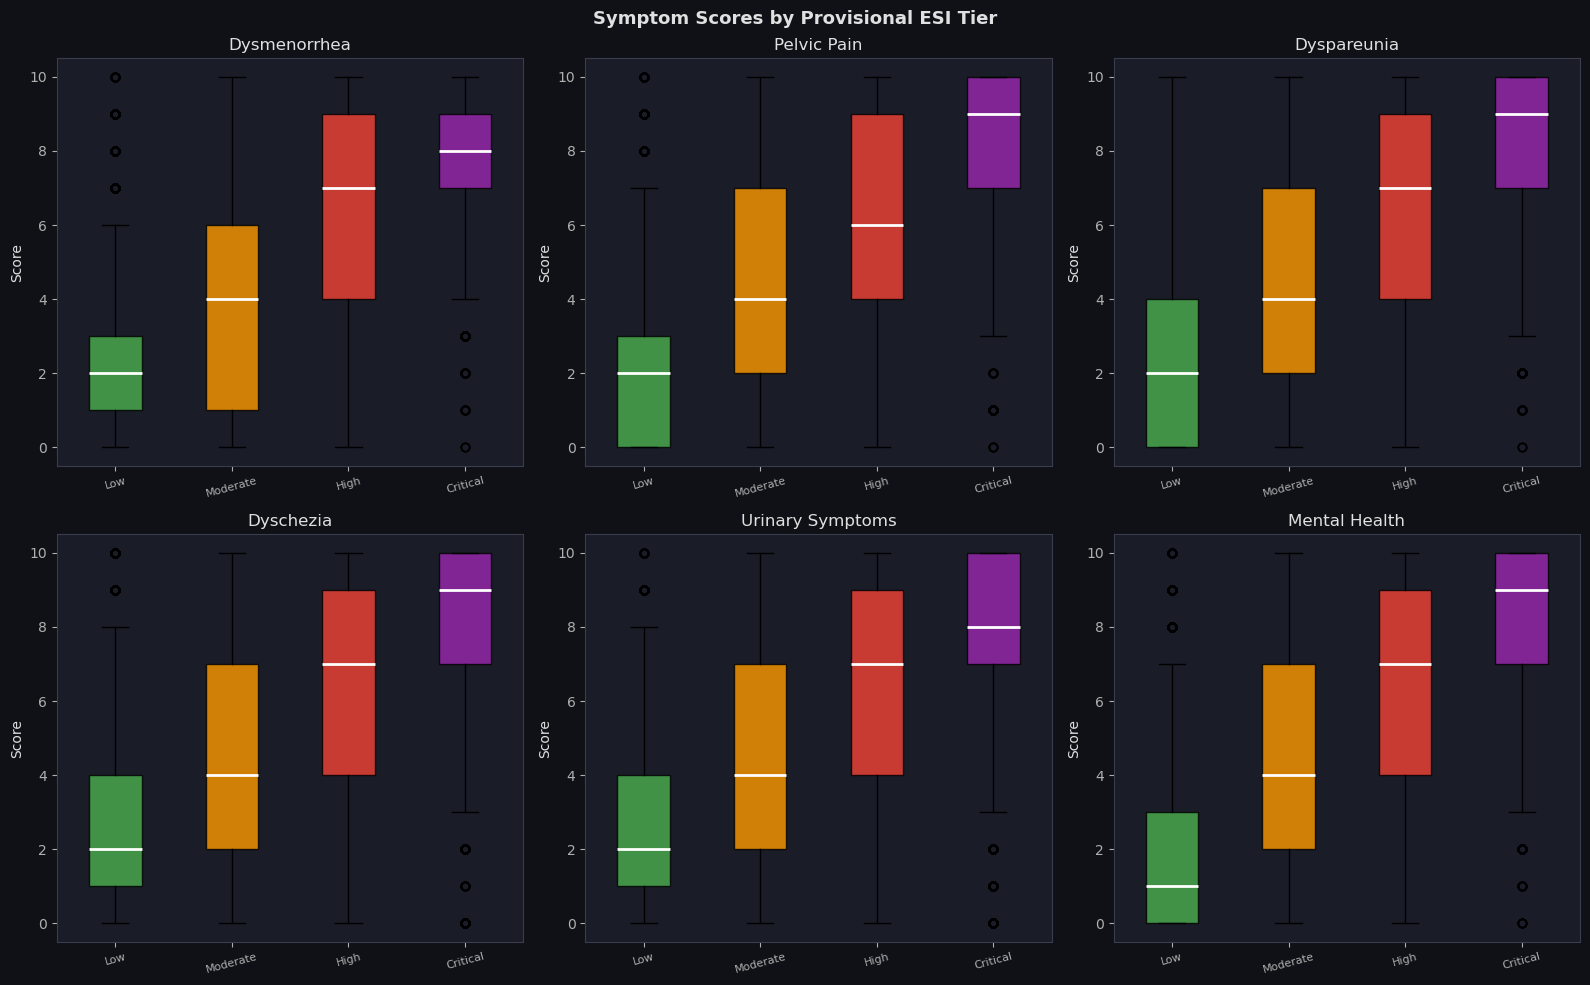

In [20]:
# ── 2.14 EDA Plot F: Symptom Scores by ESI Tier ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Symptom Scores by Provisional ESI Tier', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(SCORE_COLS):
    ax    = axes[i]
    data  = [df[df['esi_tier_prov']==t][col].dropna() for t in ESI_ORDER]
    bp    = ax.boxplot(data, patch_artist=True, notch=False,
                       medianprops=dict(color='white', linewidth=2))
    for patch, tier in zip(bp['boxes'], ESI_ORDER):
        patch.set_facecolor(PALETTE[tier]); patch.set_alpha(0.8)
    ax.set_xticklabels(ESI_ORDER, rotation=15, fontsize=8)
    ax.set_title(col.replace('_Score','').replace('_',' '))
    ax.set_ylabel('Score')

plt.tight_layout()
plt.show()


In [21]:
# ── 2.15 EDA Summary ─────────────────────────────────────────────
print("EDA SUMMARY")
print("=" * 55)
print(f"  Dataset shape (clean)       : {df.shape}")
print(f"  Embedded header rows found  : {len(header_rows)} → dropped")
print(f"  Mixed target encoding fixed : 0/1 + true/false → unified 0/1")
print(f"  Missing in working features : 0")
print(f"  Outliers removed            : 0 (clinically valid ranges)")
print(f"  Class balance               : {df['target'].mean():.1%} positive (near-balanced)")
print()
print("  Top correlated features with target:")
corrs = {col: abs(stats.pointbiserialr(df[col], df['target'])[0]) for col in FEATURES}
for col, r in sorted(corrs.items(), key=lambda x: -x[1])[:5]:
    print(f"    {col:<28} |r| = {r:.4f}")
print()
print("  Decision: No oversampling (SMOTE) needed — 54/46 balance is acceptable")
print("  Decision: No feature scaling needed — LightGBM is scale-invariant")
print("  Decision: Outliers retained — all values are clinically plausible")


EDA SUMMARY
  Dataset shape (clean)       : (480000, 18)
  Embedded header rows found  : 79 → dropped
  Mixed target encoding fixed : 0/1 + true/false → unified 0/1
  Missing in working features : 0
  Outliers removed            : 0 (clinically valid ranges)
  Class balance               : 45.8% positive (near-balanced)

  Top correlated features with target:
    Family_History               |r| = 0.2111
    Infertility_Status           |r| = 0.1688
    Dyschezia_Score              |r| = 0.1017
    Pelvic_Pain_Score            |r| = 0.0930
    Dyspareunia_Score            |r| = 0.0915

  Decision: No oversampling (SMOTE) needed — 54/46 balance is acceptable
  Decision: No feature scaling needed — LightGBM is scale-invariant
  Decision: Outliers retained — all values are clinically plausible


---
## Phase 3 — Data Preparation
Feature engineering, final cleaning, and train/val/test split.


In [22]:
# ── 3.1  Feature engineering ─────────────────────────────────────
# Composite features that capture clinical patterns the model can learn

# Total symptom burden (overall severity load)
df['total_symptom_burden'] = df[SCORE_COLS].sum(axis=1)

# Binary: any symptom scored ≥ 8 (severe threshold)
df['any_severe_symptom'] = (df[SCORE_COLS] >= 8).any(axis=1).astype(int)

# Gynaecological pain triad (three core pain symptoms)
df['pain_triad_score'] = (df['Dysmenorrhea_Score'] +
                          df['Pelvic_Pain_Score']   +
                          df['Dyspareunia_Score'])

# Bowel + urinary composite (pelvic organ involvement)
df['bowel_urinary_score'] = df['Dyschezia_Score'] + df['Urinary_Symptoms_Score']

# Years lived with a menstrual cycle (exposure duration proxy)
df['years_since_menarche'] = df['Age'] - df['Age_of_Menarche']

# BMI category (ordinal encoding)
df['bmi_category'] = pd.cut(
    df['BMI'], bins=[0, 18.5, 25, 30, 100],
    labels=[0, 1, 2, 3]
).astype(float)

ENGINEERED = ['total_symptom_burden', 'any_severe_symptom',
              'pain_triad_score', 'bowel_urinary_score',
              'years_since_menarche', 'bmi_category']
ALL_FEATURES = FEATURES + ENGINEERED

print(f"Base features      : {len(FEATURES)}")
print(f"Engineered features: {len(ENGINEERED)}")
print(f"Total features     : {len(ALL_FEATURES)}")
print()
for f in ENGINEERED:
    print(f"  + {f}")


Base features      : 12
Engineered features: 6
Total features     : 18

  + total_symptom_burden
  + any_severe_symptom
  + pain_triad_score
  + bowel_urinary_score
  + years_since_menarche
  + bmi_category


In [23]:
# ── 3.2  Prepare X / y and split 70 / 15 / 15 ───────────────────
from sklearn.model_selection import train_test_split

X_all = df[ALL_FEATURES].dropna()
y_all = df.loc[X_all.index, 'target']

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)

print(f"{'Split':<8} {'Rows':>8}   {'Share':>6}   {'Positive rate':>14}")
print("-" * 42)
for name, X, y in [('Train', X_train, y_train),
                   ('Val',   X_val,   y_val),
                   ('Test',  X_test,  y_test)]:
    print(f"{name:<8} {len(X):>8,}   {len(X)/len(X_all)*100:>5.1f}%   {y.mean():>14.3f}")

print(f"\nTotal: {len(X_all):,} rows × {len(ALL_FEATURES)} features")


Split        Rows    Share    Positive rate
------------------------------------------
Train     335,988    70.0%            0.458
Val        72,012    15.0%            0.458
Test       72,000    15.0%            0.458

Total: 480,000 rows × 18 features


In [24]:
# ── 3.3  Verify no data leakage ──────────────────────────────────
train_idx = set(X_train.index)
val_idx   = set(X_val.index)
test_idx  = set(X_test.index)

print(f"Train ∩ Val  overlap : {len(train_idx & val_idx)}")
print(f"Train ∩ Test overlap : {len(train_idx & test_idx)}")
print(f"Val   ∩ Test overlap : {len(val_idx   & test_idx)}")
print("\n✓ No overlap — clean split, no data leakage")


Train ∩ Val  overlap : 0
Train ∩ Test overlap : 0
Val   ∩ Test overlap : 0

✓ No overlap — clean split, no data leakage


---
## Phase 4 — Modelling & Evaluation
LightGBM with early stopping, 5-fold cross-validation, and full test set evaluation.


In [26]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 633.1 kB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [lightgbm]1/2 [lightgbm]


In [27]:
import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, precision_score,
    recall_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss, log_loss
)
from sklearn.model_selection import StratifiedKFold
from scipy.stats import ks_2samp
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

print("Libraries loaded ✓")


Libraries loaded ✓


In [28]:
# ── 4.1  LightGBM — find best iteration with early stopping ──────
lgb_base = lgb.LGBMClassifier(
    n_estimators    = 1000,
    learning_rate   = 0.05,
    num_leaves      = 63,
    max_depth       = -1,
    min_child_samples = 50,
    subsample       = 0.8,
    colsample_bytree = 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 0.1,
    n_jobs          = -1,
    random_state    = 42,
    verbose         = -1
)

lgb_base.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50,  verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)

best_iter      = lgb_base.best_iteration_
val_proba_base = lgb_base.predict_proba(X_val)[:, 1]
val_auc_base   = roc_auc_score(y_val, val_proba_base)

print(f"Best iteration : {best_iter}")
print(f"Validation AUC : {val_auc_base:.4f}")


Best iteration : 1000
Validation AUC : 0.9858


In [29]:
# ── 4.2  5-Fold Stratified Cross-Validation ──────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs, cv_f1s, cv_accs = [], [], []

print(f"{'Fold':<6} {'AUC':>8} {'F1':>8} {'Accuracy':>10}")
print("-" * 36)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), 1):
    Xtr, Xva = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    ytr, yva = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    m = lgb.LGBMClassifier(
        n_estimators=best_iter, learning_rate=0.05, num_leaves=63,
        min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1, n_jobs=-1, random_state=42, verbose=-1
    )
    m.fit(Xtr, ytr)
    p   = m.predict_proba(Xva)[:, 1]
    auc = roc_auc_score(yva, p)
    f1  = f1_score(yva, (p > 0.5).astype(int))
    acc = accuracy_score(yva, (p > 0.5).astype(int))
    cv_aucs.append(auc); cv_f1s.append(f1); cv_accs.append(acc)
    print(f"{fold:<6} {auc:>8.4f} {f1:>8.4f} {acc:>10.4f}")

print("-" * 36)
print(f"{'Mean':<6} {np.mean(cv_aucs):>8.4f} {np.mean(cv_f1s):>8.4f} {np.mean(cv_accs):>10.4f}")
print(f"{'Std':<6} {np.std(cv_aucs):>8.4f} {np.std(cv_f1s):>8.4f} {np.std(cv_accs):>10.4f}")


Fold        AUC       F1   Accuracy
------------------------------------
1        0.9852   0.9076     0.9152
2        0.9853   0.9085     0.9158
3        0.9861   0.9104     0.9179
4        0.9855   0.9090     0.9163
5        0.9856   0.9103     0.9178
------------------------------------
Mean     0.9855   0.9092     0.9166
Std      0.0003   0.0011     0.0011


In [30]:
# ── 4.3  Final model — train on Train + Val ──────────────────────
X_trainval = pd.concat([X_train, X_val])
y_trainval  = pd.concat([y_train, y_val])

final_model = lgb.LGBMClassifier(
    n_estimators    = best_iter,
    learning_rate   = 0.05,
    num_leaves      = 63,
    min_child_samples = 50,
    subsample       = 0.8,
    colsample_bytree = 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 0.1,
    n_jobs          = -1,
    random_state    = 42,
    verbose         = -1
)
final_model.fit(X_trainval, y_trainval)
print(f"Final model trained on {len(X_trainval):,} rows with {best_iter} estimators ✓")


Final model trained on 408,000 rows with 1000 estimators ✓


In [31]:
# ── 4.4  Test set evaluation ─────────────────────────────────────
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba > 0.5).astype(int)

metrics = {
    'AUC':           roc_auc_score(y_test, test_proba),
    'F1':            f1_score(y_test, test_pred),
    'Accuracy':      accuracy_score(y_test, test_pred),
    'Precision':     precision_score(y_test, test_pred),
    'Recall':        recall_score(y_test, test_pred),
    'Avg Precision': average_precision_score(y_test, test_proba),
    'Brier Score':   brier_score_loss(y_test, test_proba),
    'Log Loss':      log_loss(y_test, test_proba),
}

ks_stat, _ = ks_2samp(test_proba[y_test==1], test_proba[y_test==0])

print(f"{'Metric':<20} {'Value':>8}   {'Target':>8}   {'Status'}")
print("-" * 55)
for k, v in metrics.items():
    target = SUCCESS_CRITERIA.get(k, '—')
    passed = ''
    if k in SUCCESS_CRITERIA:
        passed = '✓ PASS' if v >= SUCCESS_CRITERIA[k] else '✗ FAIL'
    t_str = f'{target:.2f}' if isinstance(target, float) else target
    print(f"{k:<20} {v:>8.4f}   {t_str:>8}   {passed}")
print(f"{'KS Statistic':<20} {ks_stat:>8.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, test_pred,
      target_names=['Negative', 'Positive'], digits=4))


Metric                  Value     Target   Status
-------------------------------------------------------
AUC                    0.9856       0.92   ✓ PASS
F1                     0.9084       0.88   ✓ PASS
Accuracy               0.9160          —   
Precision              0.9084          —   
Recall                 0.9083          —   
Avg Precision          0.9838          —   
Brier Score            0.0481          —   
Log Loss               0.1695          —   
KS Statistic           0.8453

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9225    0.9225    0.9225     39008
    Positive     0.9084    0.9083    0.9084     32992

    accuracy                         0.9160     72000
   macro avg     0.9154    0.9154    0.9154     72000
weighted avg     0.9160    0.9160    0.9160     72000



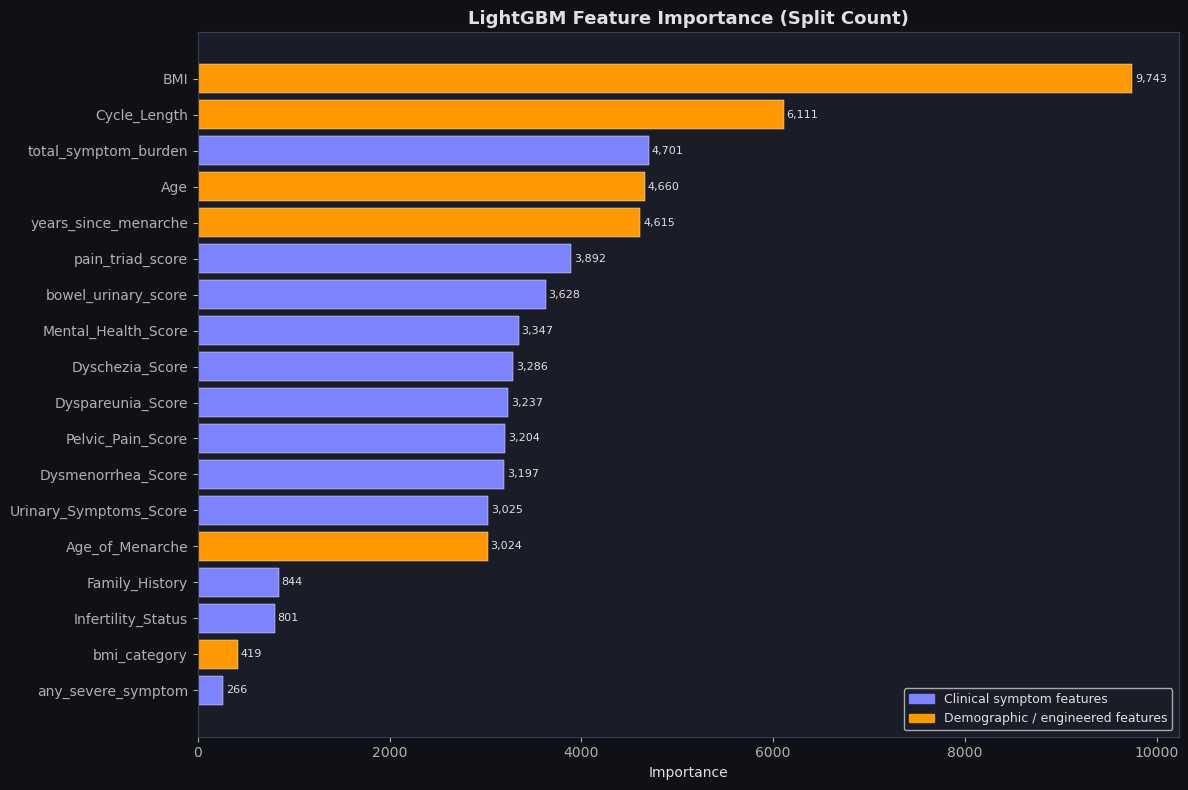

,Feature,Importance,Importance %
0,BMI,9743,15.71
1,Cycle_Length,6111,9.86
2,total_symptom_burden,4701,7.58
3,Age,4660,7.52
4,years_since_menarche,4615,7.44
5,pain_triad_score,3892,6.28
6,bowel_urinary_score,3628,5.85
7,Mental_Health_Score,3347,5.40
8,Dyschezia_Score,3286,5.30
9,Dyspareunia_Score,3237,5.22


In [32]:
# ── 4.5  Feature Importance ──────────────────────────────────────
fi = pd.DataFrame({
    'Feature':    ALL_FEATURES,
    'Importance': final_model.feature_importances_,
}).sort_values('Importance', ascending=False)
fi['Importance %'] = (fi['Importance'] / fi['Importance'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 8))
fi_sorted = fi.sort_values('Importance')
colors_fi = ['#FF9800' if f in CONTINUOUS + ['bmi_category','years_since_menarche']
             else ACCENT for f in fi_sorted['Feature']]
bars = ax.barh(fi_sorted['Feature'], fi_sorted['Importance'],
               color=colors_fi, edgecolor='white', linewidth=0.3)
for bar, val in zip(bars, fi_sorted['Importance']):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
ax.set_title('LightGBM Feature Importance (Split Count)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=ACCENT,     label='Clinical symptom features'),
                   Patch(color='#FF9800', label='Demographic / engineered features')],
          fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

display(fi.reset_index(drop=True))


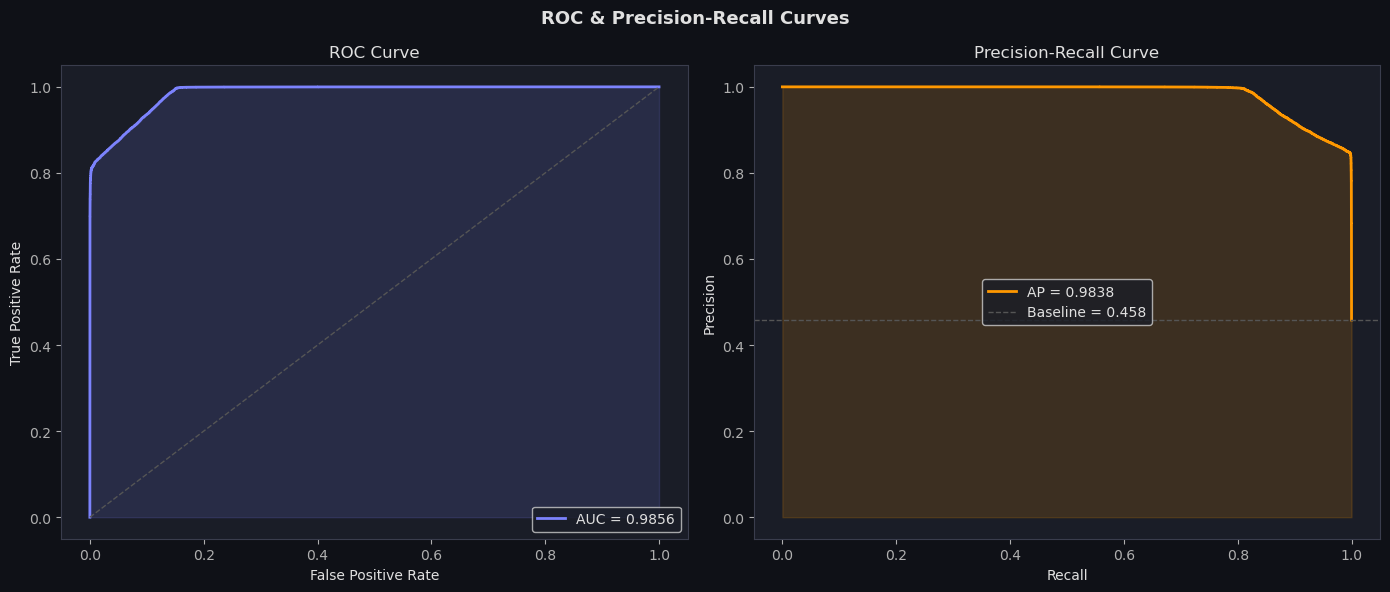

In [33]:
# ── 4.6  Evaluation Plots — ROC & PR Curves ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC & Precision-Recall Curves', fontsize=13, fontweight='bold')

# ROC
fpr, tpr, _ = roc_curve(y_test, test_proba)
auc_val      = roc_auc_score(y_test, test_proba)
axes[0].plot(fpr, tpr, color=ACCENT, lw=2, label=f'AUC = {auc_val:.4f}')
axes[0].plot([0,1],[0,1], color='#555', linestyle='--', lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.15, color=ACCENT)
axes[0].set_title('ROC Curve'); axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate'); axes[0].legend(loc='lower right')

# PR
prec, rec, _ = precision_recall_curve(y_test, test_proba)
ap = average_precision_score(y_test, test_proba)
axes[1].plot(rec, prec, color='#FF9800', lw=2, label=f'AP = {ap:.4f}')
axes[1].fill_between(rec, prec, alpha=0.15, color='#FF9800')
axes[1].axhline(y_test.mean(), color='#555', linestyle='--', lw=1,
                label=f'Baseline = {y_test.mean():.3f}')
axes[1].set_title('Precision-Recall Curve'); axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision'); axes[1].legend()

plt.tight_layout()
plt.show()


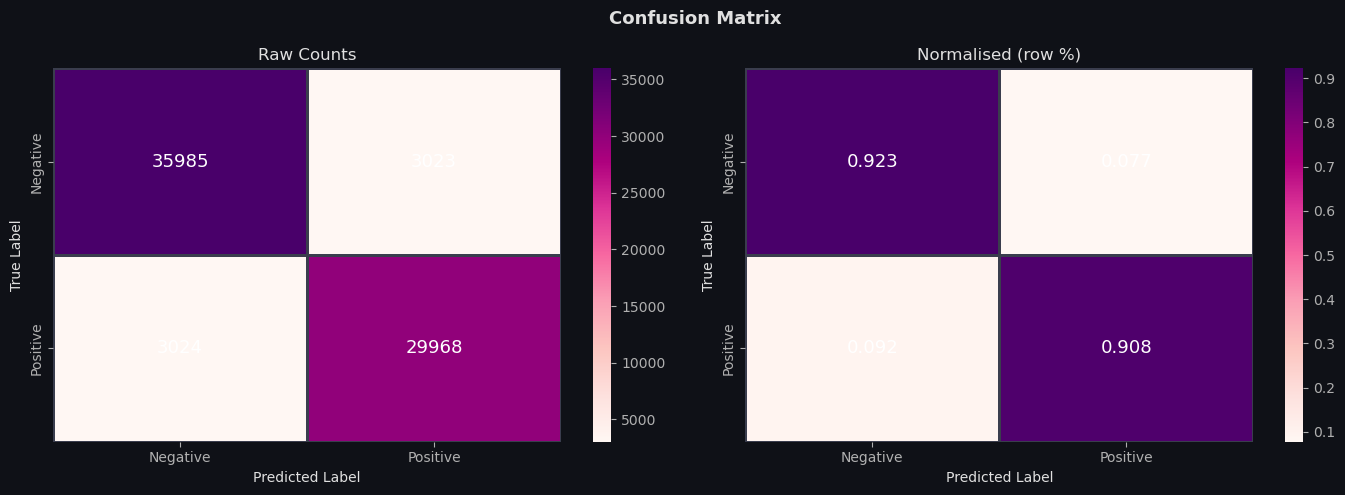

In [34]:
# ── 4.7  Confusion Matrix ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix', fontsize=13, fontweight='bold')

for i, (norm, title) in enumerate([(None,'Raw Counts'),('true','Normalised (row %)')]):
    cm  = confusion_matrix(y_test, test_pred, normalize=norm)
    fmt = '.0f' if norm is None else '.3f'
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='RdPu',
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'],
                linewidths=1, linecolor='#3a3d4d', ax=axes[i],
                annot_kws={'size': 13, 'color': 'white'})
    axes[i].set_title(title)
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


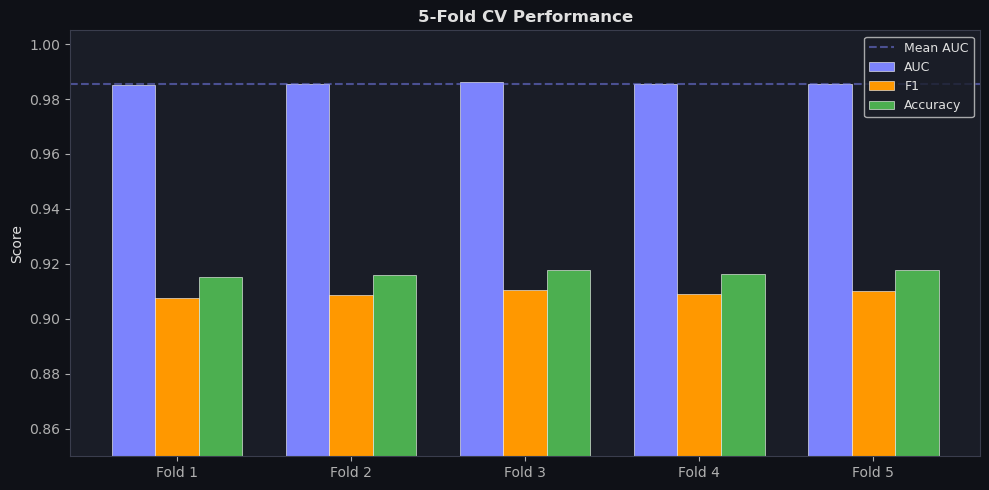

In [35]:
# ── 4.8  CV Fold Performance ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(5); w = 0.25
ax.bar(x-w, cv_aucs, w, color=ACCENT,         label='AUC',      edgecolor='white', lw=0.4)
ax.bar(x,   cv_f1s,  w, color='#FF9800',       label='F1',       edgecolor='white', lw=0.4)
ax.bar(x+w, cv_accs, w, color=PALETTE['Low'],  label='Accuracy', edgecolor='white', lw=0.4)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylim(0.85, 1.005)
ax.axhline(np.mean(cv_aucs), color=ACCENT, linestyle='--', alpha=0.5, label='Mean AUC')
ax.set_title('5-Fold CV Performance', fontsize=12, fontweight='bold')
ax.set_ylabel('Score'); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## Phase 5 — ESI Score Calibration & Output Pipeline
Probability calibration, ESI score generation, and production inference function.


Brier score before calibration : 0.0481
Brier score after  calibration : 0.0526


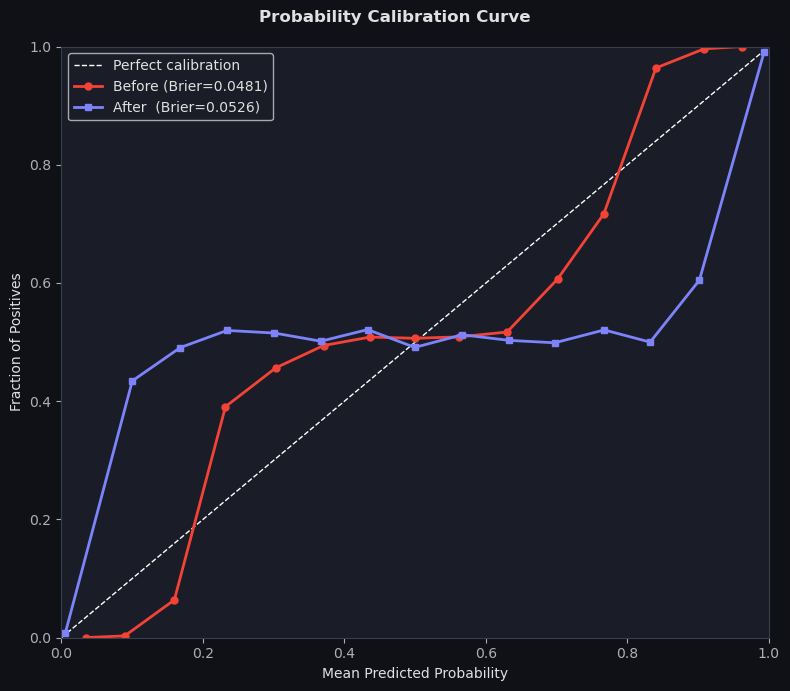

In [36]:
# ── 5.1  Platt Scaling Calibration ───────────────────────────────
# Fit a logistic regression on val-set raw probabilities
val_proba_raw = final_model.predict_proba(X_val)[:, 1].reshape(-1, 1)
platt         = LogisticRegression(max_iter=1000)
platt.fit(val_proba_raw, y_val)

# Calibrated predictions on test set
test_proba_raw = final_model.predict_proba(X_test)[:, 1].reshape(-1, 1)
cal_proba      = platt.predict_proba(test_proba_raw)[:, 1]

brier_before = brier_score_loss(y_test, test_proba)
brier_after  = brier_score_loss(y_test, cal_proba)

print(f"Brier score before calibration : {brier_before:.4f}")
print(f"Brier score after  calibration : {brier_after:.4f}")

# Calibration curve
fig, ax = plt.subplots(figsize=(8, 7))
fig.suptitle('Probability Calibration Curve', fontsize=12, fontweight='bold')
fp_raw, mp_raw = calibration_curve(y_test, test_proba, n_bins=15)
fp_cal, mp_cal = calibration_curve(y_test, cal_proba,  n_bins=15)
ax.plot([0,1],[0,1], 'w--', lw=1, label='Perfect calibration')
ax.plot(mp_raw, fp_raw, 'o-', color='#F44336', lw=2, ms=5,
        label=f'Before (Brier={brier_before:.4f})')
ax.plot(mp_cal, fp_cal, 's-', color=ACCENT,    lw=2, ms=5,
        label=f'After  (Brier={brier_after:.4f})')
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction of Positives')
ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1])
plt.tight_layout()
plt.show()


In [37]:
# ── 5.2  ESI Score & Tier Mapping ────────────────────────────────
def prob_to_esi(prob: float):
    """Map raw probability [0,1] → ESI score [1,100] → ESI tier."""
    esi_score = int(round(prob * 99 + 1))
    esi_score = max(1, min(100, esi_score))
    if   esi_score <= 25: tier = 'Low'
    elif esi_score <= 50: tier = 'Moderate'
    elif esi_score <= 75: tier = 'High'
    else:                 tier = 'Critical'
    return esi_score, tier

esi_results = pd.DataFrame({
    'probability' : cal_proba,
    'esi_score'   : [prob_to_esi(p)[0] for p in cal_proba],
    'esi_tier'    : [prob_to_esi(p)[1] for p in cal_proba],
    'true_target' : y_test.values
})

print("ESI Score statistics:")
print(esi_results['esi_score'].describe().round(2))
print()
print("ESI Tier distribution on test set:")
tier_counts = esi_results['esi_tier'].value_counts()
for tier in ESI_ORDER:
    n = tier_counts.get(tier, 0)
    print(f"  {tier:<12}: {n:>6,}  ({n/len(esi_results)*100:.1f}%)")

print()
print("ESI Tier vs True Target:")
ct = pd.crosstab(esi_results['esi_tier'], esi_results['true_target'])
ct.columns = ['Negative', 'Positive']
display(ct)


ESI Score statistics:
count    72000.00
mean        46.23
std         45.74
min          1.00
25%          1.00
50%         31.00
75%         99.00
max        100.00
Name: esi_score, dtype: float64

ESI Tier distribution on test set:
  Low         : 35,309  (49.0%)
  Moderate    :  3,809  (5.3%)
  High        :  3,696  (5.1%)
  Critical    : 29,186  (40.5%)

ESI Tier vs True Target:


,Negative,Positive
esi_tier,,
Critical,1133,28053
High,1828,1868
Low,34182,1127
Moderate,1865,1944


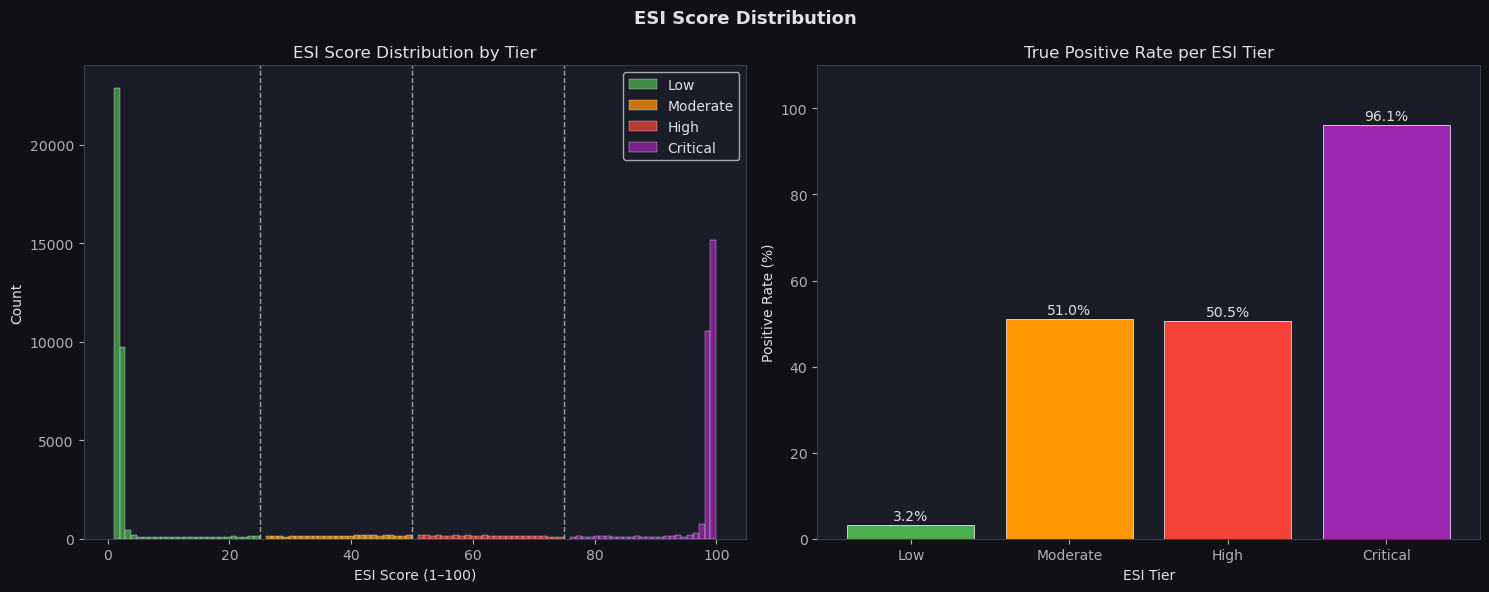

In [38]:
# ── 5.3  ESI Score Distribution Plots ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ESI Score Distribution', fontsize=13, fontweight='bold')

# Histogram by tier
for tier in ESI_ORDER:
    subset = esi_results[esi_results['esi_tier']==tier]['esi_score']
    axes[0].hist(subset, bins=25, alpha=0.75, label=tier,
                 color=PALETTE[tier], edgecolor='white', lw=0.3)
for x in [25, 50, 75]:
    axes[0].axvline(x, color='white', linestyle='--', lw=1, alpha=0.6)
axes[0].set_title('ESI Score Distribution by Tier')
axes[0].set_xlabel('ESI Score (1–100)'); axes[0].set_ylabel('Count')
axes[0].legend()

# Positive rate per tier
tier_pos_rate = esi_results.groupby('esi_tier')['true_target'].mean()[ESI_ORDER]
bars = axes[1].bar(ESI_ORDER, tier_pos_rate*100,
                    color=[PALETTE[t] for t in ESI_ORDER],
                    edgecolor='white', linewidth=0.5)
axes[1].set_title('True Positive Rate per ESI Tier')
axes[1].set_xlabel('ESI Tier'); axes[1].set_ylabel('Positive Rate (%)')
axes[1].set_ylim(0, 110)
for bar, val in zip(bars, tier_pos_rate):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


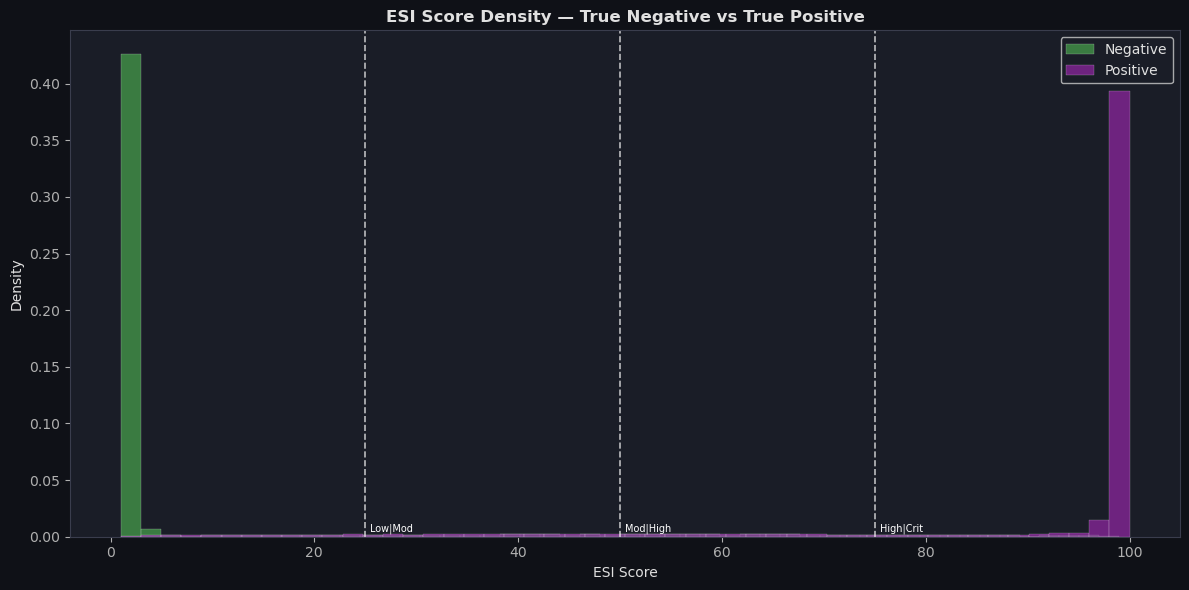

In [39]:
# ── 5.4  ESI Score Density by True Target ────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
for tgt, label, color in [(0,'Negative',PALETTE['Low']),(1,'Positive',PALETTE['Critical'])]:
    scores = esi_results[esi_results['true_target']==tgt]['esi_score']
    ax.hist(scores, bins=50, alpha=0.65, color=color, label=label,
            density=True, edgecolor='white', lw=0.2)
for x, lbl in [(25,'Low|Mod'),(50,'Mod|High'),(75,'High|Crit')]:
    ax.axvline(x, color='white', linestyle='--', lw=1.2, alpha=0.7)
    ax.text(x+0.5, 0.002, lbl, color='white', fontsize=7, va='bottom')
ax.set_title('ESI Score Density — True Negative vs True Positive', fontsize=12, fontweight='bold')
ax.set_xlabel('ESI Score'); ax.set_ylabel('Density'); ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [40]:
# ── 5.5  Production Inference Function ───────────────────────────
SCORE_DESCRIPTIONS = {
    'Low':      'Minimal endometriosis indicators. Monitor and follow up at next routine appointment.',
    'Moderate': 'Moderate indicators present. Clinical follow-up recommended within 4–6 weeks.',
    'High':     'Strong endometriosis indicators. Prioritise specialist referral within 2 weeks.',
    'Critical': 'Severe presentation. Urgent specialist referral required.'
}

SYMPTOM_LABELS = {
    'Dysmenorrhea_Score':      'Painful periods (dysmenorrhoea)',
    'Pelvic_Pain_Score':       'Pelvic pain',
    'Dyspareunia_Score':       'Pain during intercourse (dyspareunia)',
    'Dyschezia_Score':         'Painful bowel movements (dyschezia)',
    'Urinary_Symptoms_Score':  'Urinary symptoms',
    'Mental_Health_Score':     'Mental health impact',
}

def predict_esi(input_dict: dict) -> dict:
    """
    Production inference function for EndoScan structured path.

    Args:
        input_dict: dict with questionnaire keys matching FEATURES

    Returns:
        dict with esi_score, esi_tier, probability, description,
              top_symptoms, family_history, infertility_flag,
              model_version, path
    """
    row = {f: input_dict.get(f, 0) for f in FEATURES}
    df_row = pd.DataFrame([row], dtype=float)

    sc = [row[c] for c in SCORE_COLS]
    df_row['total_symptom_burden'] = sum(sc)
    df_row['any_severe_symptom']   = int(any(s >= 8 for s in sc))
    df_row['pain_triad_score']     = sc[0] + sc[1] + sc[2]
    df_row['bowel_urinary_score']  = sc[3] + sc[4]
    df_row['years_since_menarche'] = row['Age'] - row['Age_of_Menarche']
    bmi = row['BMI']
    df_row['bmi_category']         = (0 if bmi < 18.5 else
                                      1 if bmi < 25   else
                                      2 if bmi < 30   else 3)

    raw_prob  = final_model.predict_proba(df_row[ALL_FEATURES])[:, 1][0]
    cal_prob  = platt.predict_proba([[raw_prob]])[:, 1][0]

    esi_score, esi_tier = prob_to_esi(cal_prob)

    top_symptoms = [SYMPTOM_LABELS[k]
                    for k in sorted(SYMPTOM_LABELS, key=lambda x: -input_dict.get(x, 0))
                    if input_dict.get(k, 0) >= 6][:3]

    return {
        'esi_score':        esi_score,
        'esi_tier':         esi_tier,
        'probability':      round(float(cal_prob), 4),
        'description':      SCORE_DESCRIPTIONS[esi_tier],
        'top_symptoms':     top_symptoms or ['No severe symptoms reported'],
        'family_history':   bool(input_dict.get('Family_History', 0)),
        'infertility_flag': bool(input_dict.get('Infertility_Status', 0)),
        'model_version':    'endoscan_lgb_v1.0',
        'path':             'structured_classifier'
    }

print("predict_esi() function defined ✓")


predict_esi() function defined ✓


In [41]:
# ── 5.6  Sample Inferences ───────────────────────────────────────
import json

test_cases = {
    'High-symptom (expected: Critical/High)': {
        'Age': 28, 'BMI': 22.5, 'Cycle_Length': 26, 'Age_of_Menarche': 12,
        'Dysmenorrhea_Score': 9, 'Pelvic_Pain_Score': 8, 'Dyspareunia_Score': 7,
        'Dyschezia_Score': 6, 'Urinary_Symptoms_Score': 5, 'Mental_Health_Score': 7,
        'Family_History': 1, 'Infertility_Status': 1
    },
    'Mid-symptom (expected: Moderate/High)': {
        'Age': 32, 'BMI': 26.0, 'Cycle_Length': 30, 'Age_of_Menarche': 13,
        'Dysmenorrhea_Score': 5, 'Pelvic_Pain_Score': 5, 'Dyspareunia_Score': 4,
        'Dyschezia_Score': 3, 'Urinary_Symptoms_Score': 3, 'Mental_Health_Score': 4,
        'Family_History': 1, 'Infertility_Status': 0
    },
    'Low-symptom (expected: Low)': {
        'Age': 35, 'BMI': 25.0, 'Cycle_Length': 28, 'Age_of_Menarche': 13,
        'Dysmenorrhea_Score': 2, 'Pelvic_Pain_Score': 1, 'Dyspareunia_Score': 0,
        'Dyschezia_Score': 1, 'Urinary_Symptoms_Score': 2, 'Mental_Health_Score': 1,
        'Family_History': 0, 'Infertility_Status': 0
    },
}

for label, case in test_cases.items():
    result = predict_esi(case)
    print(f"\n{'─'*55}")
    print(f"Case: {label}")
    print(f"{'─'*55}")
    print(json.dumps(result, indent=2))



───────────────────────────────────────────────────────
Case: High-symptom (expected: Critical/High)
───────────────────────────────────────────────────────
{
  "esi_score": 98,
  "esi_tier": "Critical",
  "probability": 0.983,
  "description": "Severe presentation. Urgent specialist referral required.",
  "top_symptoms": [
    "Painful periods (dysmenorrhoea)",
    "Pelvic pain",
    "Pain during intercourse (dyspareunia)"
  ],
  "family_history": true,
  "infertility_flag": true,
  "model_version": "endoscan_lgb_v1.0",
  "path": "structured_classifier"
}

───────────────────────────────────────────────────────
Case: Mid-symptom (expected: Moderate/High)
───────────────────────────────────────────────────────
{
  "esi_score": 95,
  "esi_tier": "Critical",
  "probability": 0.9518,
  "description": "Severe presentation. Urgent specialist referral required.",
  "top_symptoms": [
    "No severe symptoms reported"
  ],
  "family_history": true,
  "infertility_flag": false,
  "model_versio

---
## Phase 6 — Deployment
Serialise the model and document the integration contract for the fusion layer.


In [ ]:
import joblib, json

# Save model + Platt scaler + feature list
joblib.dump({'model': final_model, 'platt': platt},
            'endoscan_classifier.pkl')
joblib.dump(ALL_FEATURES, 'feature_list.pkl')

# Metadata
model_meta = {
    'model_version':        'endoscan_lgb_v1.0',
    'model_type':           'LightGBM + Platt calibration',
    'n_features':           len(ALL_FEATURES),
    'features':             ALL_FEATURES,
    'base_features':        FEATURES,
    'engineered_features':  ENGINEERED,
    'train_rows':           len(X_trainval),
    'test_rows':            len(X_test),
    'best_iteration':       int(best_iter),
    'test_metrics':         {k: round(v, 4) for k, v in metrics.items()},
    'cv_metrics': {
        'auc_mean': round(np.mean(cv_aucs), 4), 'auc_std': round(np.std(cv_aucs), 4),
        'f1_mean':  round(np.mean(cv_f1s),  4), 'f1_std':  round(np.std(cv_f1s),  4),
    },
    'esi_tier_thresholds':  {'Low':'1–25','Moderate':'26–50','High':'51–75','Critical':'76–100'},
    'fusion_layer_input':   'esi_score (int 1–100) + esi_tier (str)',
    'output_path':          'structured_classifier',
}

with open('model_metadata.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print("Saved: endoscan_classifier.pkl")
print("Saved: feature_list.pkl")
print("Saved: model_metadata.json")


In [ ]:
# ── 6.1  Load & verify saved model ───────────────────────────────
artefacts    = joblib.load('endoscan_classifier.pkl')
loaded_model = artefacts['model']
loaded_platt = artefacts['platt']
loaded_feats = joblib.load('feature_list.pkl')

verify_proba = loaded_model.predict_proba(X_test[:5])[:, 1]
print("Model load verification ✓")
print(f"First 5 probabilities: {verify_proba.round(4)}")


In [ ]:
# ── 6.2  Fusion Layer Integration Contract ────────────────────────
contract = """
╔══════════════════════════════════════════════════════════════╗
║       EndoScan — Fusion Layer Integration Contract           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  NLP PATH (live)                                             ║
║    Input  : free-text symptom description                    ║
║    Output : { esi_score: int, esi_tier: str, ... }           ║
║                                                              ║
║  STRUCTURED PATH (this model)                                ║
║    Input  : questionnaire dict (12 base fields)              ║
║    Output : { esi_score: int, esi_tier: str, ... }           ║
║             call: predict_esi(input_dict)                    ║
║                                                              ║
║  FUSION LAYER                                                ║
║    When both paths run:                                      ║
║      final_score = round(w_nlp * nlp_score +                 ║
║                          w_struct * struct_score)            ║
║      final_tier  = score_to_tier(final_score)                ║
║                                                              ║
║    When only structured path runs:                           ║
║      final_score = struct_score                              ║
║      final_tier  = struct_tier                               ║
║                                                              ║
║  Score range    : 1–100 (synonymous across both paths)       ║
║  Tiers          : Low (1–25) | Moderate (26–50)              ║
║                   High (51–75) | Critical (76–100)           ║
╚══════════════════════════════════════════════════════════════╝
"""
print(contract)


In [ ]:
# ── 6.3  Final Summary ────────────────────────────────────────────
print("=" * 55)
print("  ENDOSCAN STRUCTURED CLASSIFIER — FINAL SUMMARY")
print("=" * 55)
print(f"  Model          : LightGBM + Platt calibration")
print(f"  Features       : {len(ALL_FEATURES)} ({len(FEATURES)} base + {len(ENGINEERED)} engineered)")
print(f"  Training rows  : {len(X_trainval):,}")
print()
print(f"  CV  AUC  : {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")
print(f"  CV  F1   : {np.mean(cv_f1s):.4f} ± {np.std(cv_f1s):.4f}")
print()
print(f"  Test AUC : {metrics['AUC']:.4f}  {'✓ PASS' if metrics['AUC'] >= 0.92 else '✗ FAIL'} (target ≥ 0.92)")
print(f"  Test F1  : {metrics['F1']:.4f}  {'✓ PASS' if metrics['F1']  >= 0.88 else '✗ FAIL'} (target ≥ 0.88)")
print(f"  Test Acc : {metrics['Accuracy']:.4f}")
print(f"  KS Stat  : {ks_stat:.4f}  (strong discrimination)")
print()
print(f"  Artefacts: endoscan_classifier.pkl")
print(f"             feature_list.pkl")
print(f"             model_metadata.json")
print("=" * 55)
